In [1]:
import os
import sys
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
#import nipes_data_fcts as nidf
import me_data_fcts as medf
#from statannotations.Annotator import Annotator
import umap
from sklearn.preprocessing import StandardScaler


In [2]:
# if you modify me_data_fcts.py and want to reload without restarting the kernel
import importlib
importlib.reload(medf)

<module 'me_data_fcts' from '/home/leni/git/AREFramework/experiments/scripts/me_data_fcts.py'>

In [51]:
repo_folder = "/media/leni/DATADRIVE1/alife_2025/"
experiments = {
    "directory" :  ['meimflat', 'meimhill', 'meimholes', 'meimobs', 'meimrough', 'meimholly' ],
    "name" :       ['flat', 'hill', 'holes', 'obstacles', 'rough', 'holyrood'],
    "print_name" : ['Flat', 'Hill', 'Holes', 'Obstacles', 'Rough', 'Holyrood'],
}

In [9]:
def load_experiment(name, folders):
    experiments_loaded = 0
    exp_fits = []
    for folder in folders:
        #print(folder)
        ids, parents, fitnesses, evals, deltas, replicate_index = medf.load_fitness(folder + "/fitness.csv")
        eval_times = medf.load_comp_time_dict(folder + "/times.csv")
        fits = [[i, p[0], p[1], eval_times[i][0]/(1000000*3600), eval_times[i][1]/(1000000*3600), f, folder, r] 
                for i, p, f, r in zip(ids,parents,fitnesses, replicate_index)]
        exp_fits += fits
        experiments_loaded += 1
        print(folder, " -- Robots: ", len(ids))
    fit_data = pd.DataFrame(data=exp_fits,columns=[      "robot index",
                                                         "parent 1",
                                                         "parent 2",
                                                         "evaluation time",
                                                         "time",
                                                         "fitness",
                                                         "replicate", 
                                                         "replicate_index"])
    fit_data["environment"] = name
    print("Total experiments loaded: ", experiments_loaded, "-- Total robots: ", len(fit_data))
    return fit_data

In [10]:
def load_morphology(name, folders):
    exp_descs = []
    experiments_loaded = 0
    for folder in folders:
        #parent_ids = medf.load_parent_pool(folder + "/parent_pool.csv")
        descriptors = medf.load_feature_descriptor(folder + "/morph_features.csv")
        #print(descriptors[-1])
        descs = [[int(d[0])] + d[1:5] + [d[5]*16,
                                         d[6]*16,
                                         d[7]*16,
                                         d[8]*16]
                                           + d[9:]  + [folder] 
                 for d in descriptors]
        #print(descs[-1])
        #parent_descs += medf.filter_to_parent_pool(descs,parent_ids)
        exp_descs += descs        
        print(folder, " -- Robots: ", len(descs))
        experiments_loaded += 1
    data = pd.DataFrame(data=exp_descs,columns=[
                                                            "robot index",
                                                            "width",
                                                            "depth",
                                                            "height",
                                                            "voxels",
                                                            "wheels",
                                                            "sensors",
                                                            "limbs",
                                                            "casters",
                                                            "norm",
                                                            "skeleton norm",
                                                            "components norm",
                                                            "replicate_index", 
                                                            "replicate"])
    data["environment"] = name
    print("Total experiments loaded: ", experiments_loaded, "-- Total robots: ", len(data))
    return data

In [58]:
# Load fitness data
robot_data = []
for idx, exps in enumerate(experiments['directory']):
    print(exps)
    folders = []
    data = []
    for folder in os.listdir(repo_folder + exps):
        for fold in os.listdir(repo_folder + exps + '/' + folder):
            folders.append(repo_folder + exps + '/' + folder + '/' + fold)
    data = load_experiment(experiments['name'][idx], folders)
    robot_data.append(data)


meimflat
/media/leni/DATADRIVE1/alife_2025/meimflat/55742_1/meim_11_3_17-59-57-7269-4229270083  -- Robots:  10000
/media/leni/DATADRIVE1/alife_2025/meimflat/55742_10/meim_12_3_1-54-59-9138-4171306948  -- Robots:  10000
/media/leni/DATADRIVE1/alife_2025/meimflat/55742_2/meim_11_3_17-59-56-6384-2102594713  -- Robots:  10000
/media/leni/DATADRIVE1/alife_2025/meimflat/55742_3/meim_11_3_17-59-58-8527-4068923784  -- Robots:  10000
/media/leni/DATADRIVE1/alife_2025/meimflat/55742_4/meim_11_3_17-59-57-7377-2053156979  -- Robots:  10036
/media/leni/DATADRIVE1/alife_2025/meimflat/55742_5/meim_11_3_17-59-57-7862-293875990  -- Robots:  10000
/media/leni/DATADRIVE1/alife_2025/meimflat/55742_6/meim_11_3_17-59-57-7467-1188062065  -- Robots:  10002
/media/leni/DATADRIVE1/alife_2025/meimflat/55742_7/meim_11_3_17-59-59-9003-1516430376  -- Robots:  10024
/media/leni/DATADRIVE1/alife_2025/meimflat/55742_8/meim_11_3_19-16-10-816-2370462392  -- Robots:  10046
/media/leni/DATADRIVE1/alife_2025/meimflat/55742

In [59]:
# loading descriptor data
robot_desc_data = []
for idx, exps in enumerate(experiments['directory']):
    print(exps)
    folders = []
    data = []
    for folder in os.listdir(repo_folder + exps):
        for fold in os.listdir(repo_folder + exps + '/' + folder):
            folders.append(repo_folder + exps + '/' + folder + '/' + fold)
    data = load_morphology(experiments['name'][idx], folders)
    robot_desc_data.append(data)

meimflat
/media/leni/DATADRIVE1/alife_2025/meimflat/55742_1/meim_11_3_17-59-57-7269-4229270083  -- Robots:  10000
/media/leni/DATADRIVE1/alife_2025/meimflat/55742_10/meim_12_3_1-54-59-9138-4171306948  -- Robots:  10000
/media/leni/DATADRIVE1/alife_2025/meimflat/55742_2/meim_11_3_17-59-56-6384-2102594713  -- Robots:  10000
/media/leni/DATADRIVE1/alife_2025/meimflat/55742_3/meim_11_3_17-59-58-8527-4068923784  -- Robots:  10000
/media/leni/DATADRIVE1/alife_2025/meimflat/55742_4/meim_11_3_17-59-57-7377-2053156979  -- Robots:  10036
/media/leni/DATADRIVE1/alife_2025/meimflat/55742_5/meim_11_3_17-59-57-7862-293875990  -- Robots:  10000
/media/leni/DATADRIVE1/alife_2025/meimflat/55742_6/meim_11_3_17-59-57-7467-1188062065  -- Robots:  10002
/media/leni/DATADRIVE1/alife_2025/meimflat/55742_7/meim_11_3_17-59-59-9003-1516430376  -- Robots:  10024
/media/leni/DATADRIVE1/alife_2025/meimflat/55742_8/meim_11_3_19-16-10-816-2370462392  -- Robots:  10046
/media/leni/DATADRIVE1/alife_2025/meimflat/55742

In [60]:
# Concat all the parents data
fit_data = pd.concat(robot_data).reset_index(drop=True)
#fit_data = fit_data[fit_data["replicate_index"] <= 6000]

# Selecting highest robot per replicate
fit_max_data = []
for env in experiments["name"]:
    tmp_data = fit_data.loc[fit_data["environment"] == env]
    for rep in tmp_data["replicate"].drop_duplicates():
        tmp_data2 = tmp_data.loc[tmp_data["replicate"] == rep]
        fit_max_data.append(pd.DataFrame(tmp_data2.max(numeric_only=True)).transpose())
        fit_max_data[-1]["replicate"] = rep
        fit_max_data[-1]["environment"] = env
            
fit_max_data = pd.concat(fit_max_data)
fit_max_data.index = [i for i in range(len(fit_max_data))]

In [61]:
desc_data = pd.concat(robot_desc_data).reset_index(drop=True)
desc_data = pd.merge(desc_data, fit_data, how="left",
                     on=["robot index", "replicate", "environment", "replicate_index"])
desc_data = desc_data.drop_duplicates(subset=['robot index','replicate'])
#desc_data = desc_data[desc_data["replicate_index"] <= 6000]


# Exploration score

/tmp/ipykernel_25871/2931069552.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(experiments["print_name"])


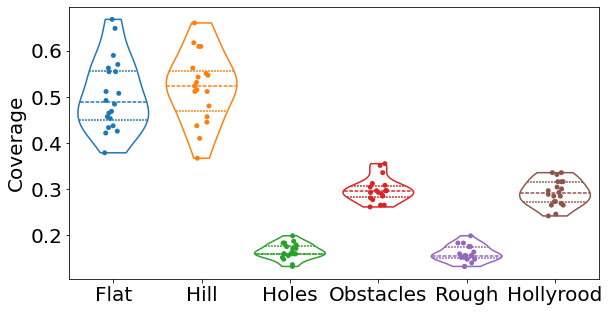

In [34]:
fig = plt.gcf()
fig.set_size_inches(9.5,5)
ax = sns.violinplot(fit_max_data,x="environment",hue="environment",y="fitness",fill=False,inner="quart", cut=0)
sns.stripplot(fit_max_data,x="environment",hue="environment",y="fitness")
ax.set_xlabel("")
ax.set_xticklabels(experiments["print_name"])
ax.set_ylabel("Coverage")
ax.xaxis.label.set_size(20)
ax.yaxis.label.set_size(20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.savefig("img_alife25/exploration_score.png")


In [12]:
avg_fitness_per_replicate_index = fit_data.groupby(['environment', 'replicate_index'])['fitness'].mean().reset_index()
avg_fitness_per_replicate_index.rename(columns={'fitness': 'average_fitness'}, inplace=True)
avg_fitness_per_replicate_index

,environment,replicate_index,average_fitness
0,flat,0,0.022852
1,flat,1,0.030664
2,flat,2,0.032422
3,flat,3,0.028906
4,flat,4,0.031836
...,...,...,...
60276,rough,10043,0.028646
60277,rough,10044,0.021484
60278,rough,10045,0.021484
60279,rough,10046,0.042969


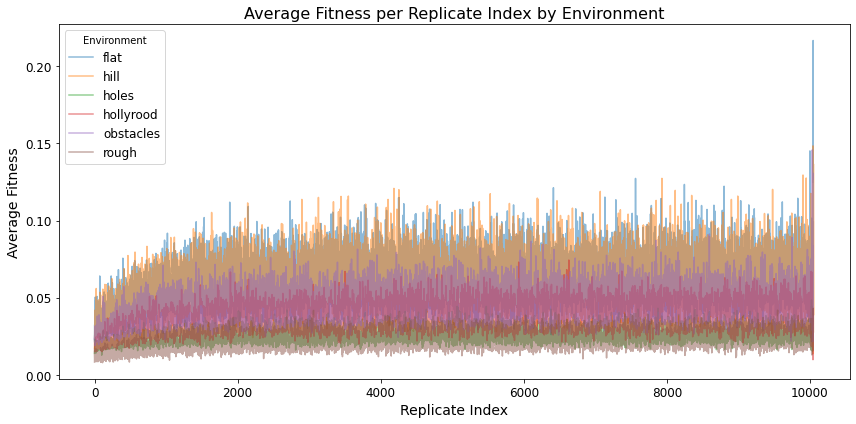

<Figure size 432x288 with 0 Axes>

In [35]:
fig = plt.gcf()
fig.set_size_inches(12, 6)
ax = sns.lineplot(
  data=avg_fitness_per_replicate_index,
  x="replicate_index",
  y="average_fitness",
  hue="environment",
  alpha=0.5
)
ax.set_title("Average Fitness per Replicate Index by Environment", fontsize=16)
ax.set_xlabel("Replicate Index", fontsize=14)
ax.set_ylabel("Average Fitness", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title="Environment", fontsize=12)
plt.tight_layout()
plt.show()
plt.savefig("img_alife25/fitness.png")


# Components diversity

(array([0. , 0.1, 0.2, 0.3, 0.4, 0.5]),
 [Text(0, 0.0, '0%'),
  Text(0, 0.1, '10%'),
  Text(0, 0.2, '20%'),
  Text(0, 0.30000000000000004, '30%'),
  Text(0, 0.4, '40%'),
  Text(0, 0.5, '50%')])

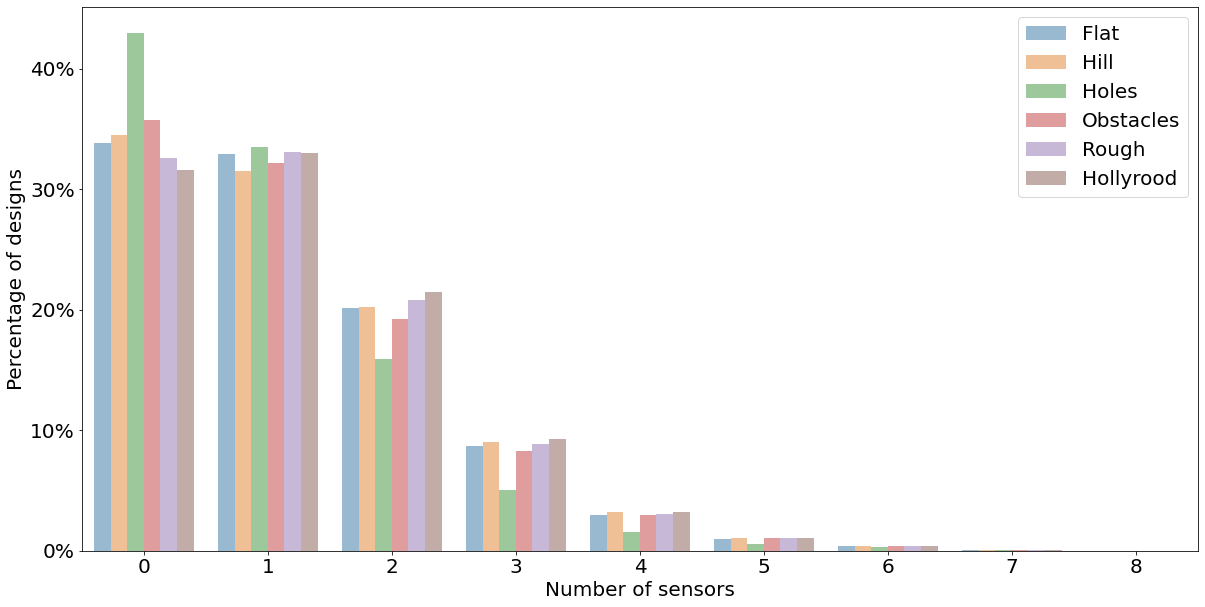

In [14]:
fig = plt.gcf()
fig.set_size_inches(20,10)
df = pd.crosstab(desc_data['environment'], desc_data['sensors'], normalize='index')
df1 = df.melt(var_name='sensors', value_name='percentage', ignore_index=False).reset_index()
ax = sns.barplot(data=df1,x="sensors",y="percentage",hue="environment",hue_order=experiments["name"],alpha=0.5)
ax.yaxis.label.set_size(20)
ax.yaxis.set_major_formatter('{x:.0%}')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles,labels=experiments["print_name"],fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.xaxis.label.set_size(20)
ax.set_xlabel("Number of sensors")
ax.set_ylabel("Percentage of designs")
ax.yaxis.label.set_size(20)
ax.xaxis.set_major_formatter('{x:}')
plt.yticks(fontsize=20)

(array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 ]),
 [Text(0, 0.0, '0%'),
  Text(0, 0.05, '5%'),
  Text(0, 0.1, '10%'),
  Text(0, 0.15000000000000002, '15%'),
  Text(0, 0.2, '20%'),
  Text(0, 0.25, '25%'),
  Text(0, 0.30000000000000004, '30%'),
  Text(0, 0.35000000000000003, '35%'),
  Text(0, 0.4, '40%')])

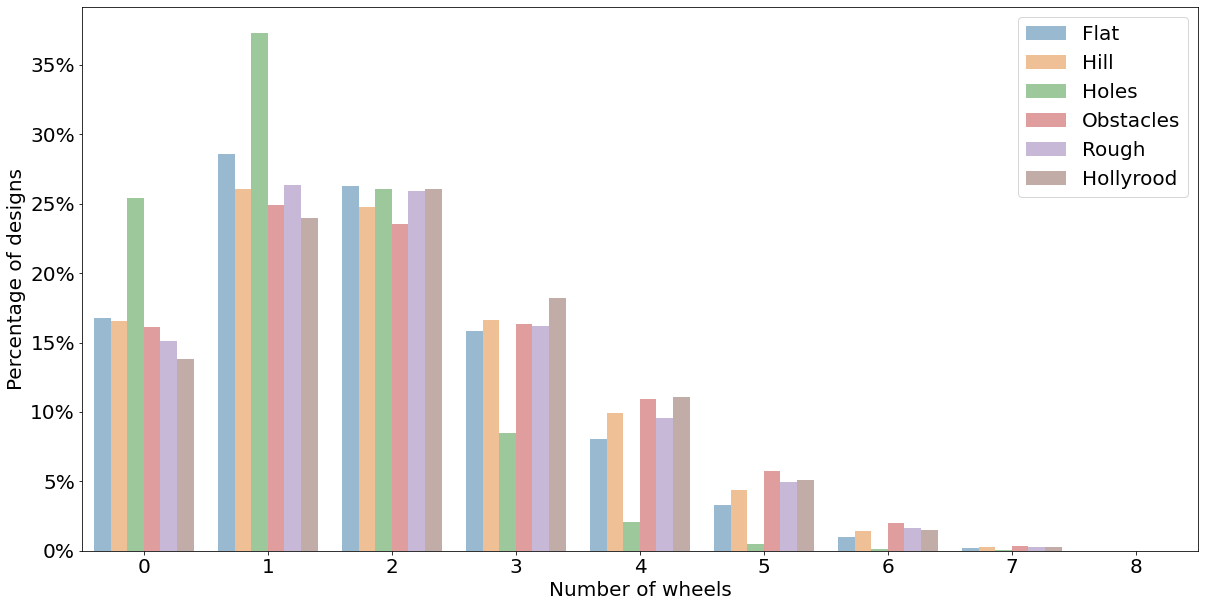

In [15]:
fig = plt.gcf()
fig.set_size_inches(20,10)
df = pd.crosstab(desc_data['environment'], desc_data['wheels'], normalize='index')
df1 = df.melt(var_name='wheels', value_name='percentage', ignore_index=False).reset_index()
ax = sns.barplot(data=df1,x="wheels",y="percentage",hue="environment",hue_order=experiments["name"],alpha=0.5)
ax.yaxis.label.set_size(20)
ax.yaxis.set_major_formatter('{x:.0%}')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles,labels=experiments["print_name"],fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.xaxis.label.set_size(20)
ax.set_xlabel("Number of wheels")
ax.set_ylabel("Percentage of designs")
ax.yaxis.label.set_size(20)
ax.xaxis.set_major_formatter('{x:}')
plt.yticks(fontsize=20)

(array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]),
 [Text(0, 0.0, '0%'),
  Text(0, 0.1, '10%'),
  Text(0, 0.2, '20%'),
  Text(0, 0.30000000000000004, '30%'),
  Text(0, 0.4, '40%'),
  Text(0, 0.5, '50%'),
  Text(0, 0.6000000000000001, '60%'),
  Text(0, 0.7000000000000001, '70%')])

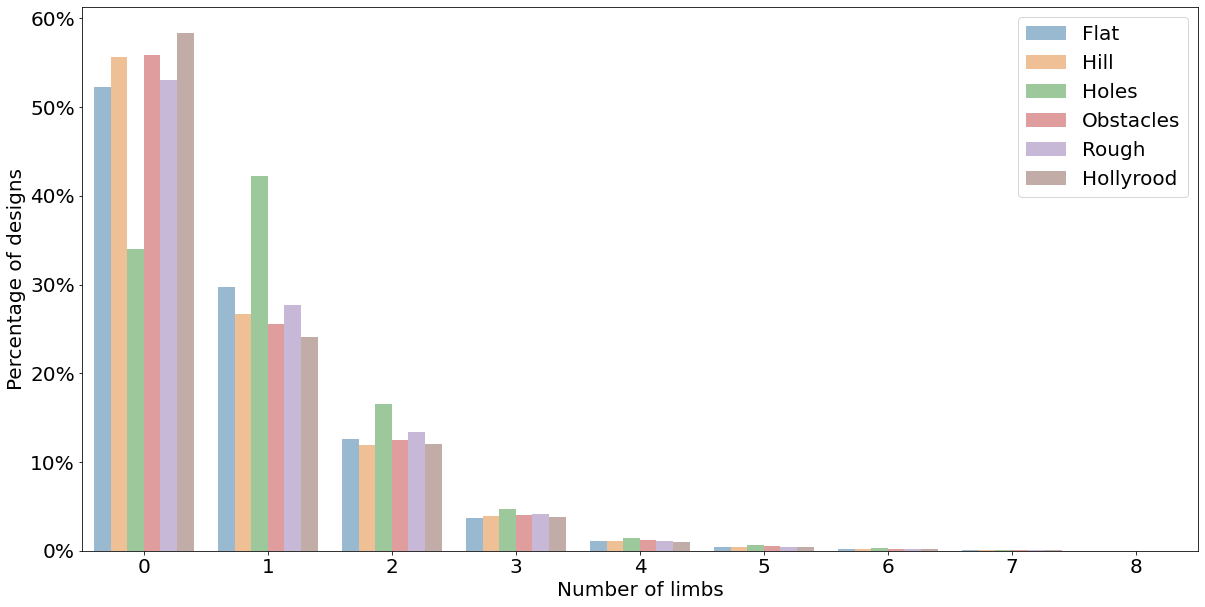

In [16]:
fig = plt.gcf()
fig.set_size_inches(20,10)
df = pd.crosstab(desc_data['environment'], desc_data['limbs'], normalize='index')
df1 = df.melt(var_name='limbs', value_name='percentage', ignore_index=False).reset_index()
ax = sns.barplot(data=df1,x="limbs",y="percentage",hue="environment",hue_order=experiments["name"],alpha=0.5)
ax.yaxis.label.set_size(20)
ax.yaxis.set_major_formatter('{x:.0%}')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles,labels=experiments["print_name"],fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.xaxis.label.set_size(20)
ax.set_xlabel("Number of limbs")
ax.set_ylabel("Percentage of designs")
ax.yaxis.label.set_size(20)
ax.xaxis.set_major_formatter('{x:}')
plt.yticks(fontsize=20)

(array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]),
 [Text(0, 0.0, '0%'),
  Text(0, 0.1, '10%'),
  Text(0, 0.2, '20%'),
  Text(0, 0.30000000000000004, '30%'),
  Text(0, 0.4, '40%'),
  Text(0, 0.5, '50%'),
  Text(0, 0.6000000000000001, '60%'),
  Text(0, 0.7000000000000001, '70%'),
  Text(0, 0.8, '80%')])

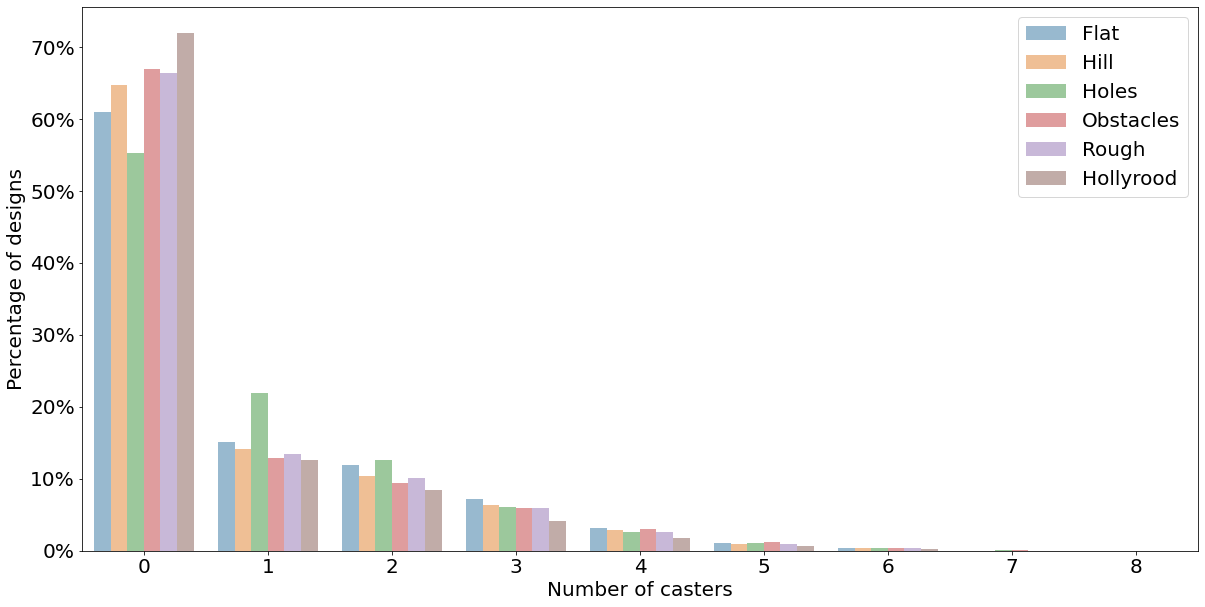

In [17]:
fig = plt.gcf()
fig.set_size_inches(20,10)
df = pd.crosstab(desc_data['environment'], desc_data['casters'], normalize='index')
df1 = df.melt(var_name='casters', value_name='percentage', ignore_index=False).reset_index()
ax = sns.barplot(data=df1,x="casters",y="percentage",hue="environment",hue_order=experiments["name"],alpha=0.5)
ax.yaxis.label.set_size(20)
ax.yaxis.set_major_formatter('{x:.0%}')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles,labels=experiments["print_name"],fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.xaxis.label.set_size(20)
ax.set_xlabel("Number of casters")
ax.set_ylabel("Percentage of designs")
ax.yaxis.label.set_size(20)
ax.xaxis.set_major_formatter('{x:}')
plt.yticks(fontsize=20)

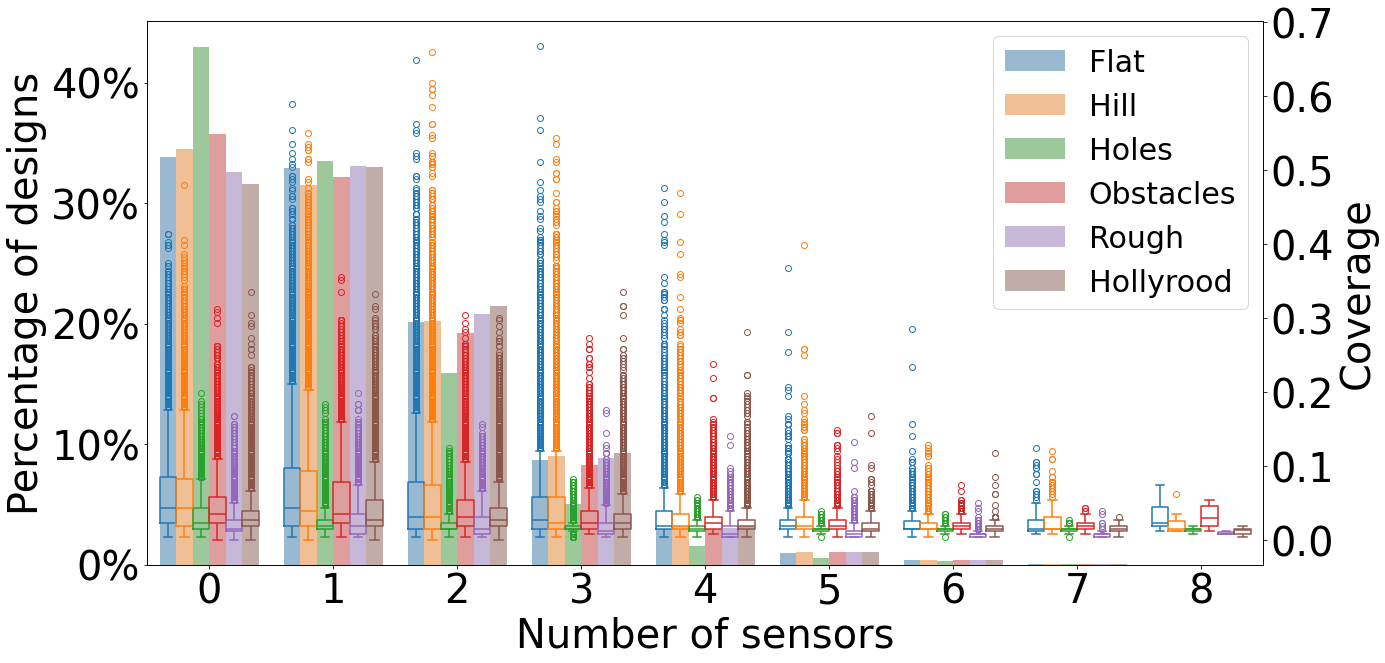

In [36]:
fig = plt.gcf()
fig.set_size_inches(20,10)
df = pd.crosstab(desc_data['environment'], desc_data['sensors'], normalize='index')
df1 = df.melt(var_name='sensors', value_name='percentage', ignore_index=False).reset_index()
ax = sns.barplot(data=df1,x="sensors",y="percentage",hue="environment",hue_order=experiments["name"],alpha=0.5)
ax.yaxis.label.set_size(40)
ax.yaxis.set_major_formatter('{x:.0%}')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles,labels=experiments["print_name"],fontsize=30)
plt.xticks(fontsize=40)
plt.yticks(fontsize=40)
ax.xaxis.label.set_size(40)
ax.set_xlabel("Number of sensors")
ax.set_ylabel("Percentage of designs")
ax = plt.twinx()
sns.boxplot(data=desc_data,x="sensors",y="fitness",hue="environment",ax=ax,fill=False,legend=False)
ax.set_ylabel("Coverage")
ax.yaxis.label.set_size(40)
ax.xaxis.set_major_formatter('{x:}')
plt.yticks(fontsize=40)
plt.savefig("img_alife25/distribution_sensors_score.png")

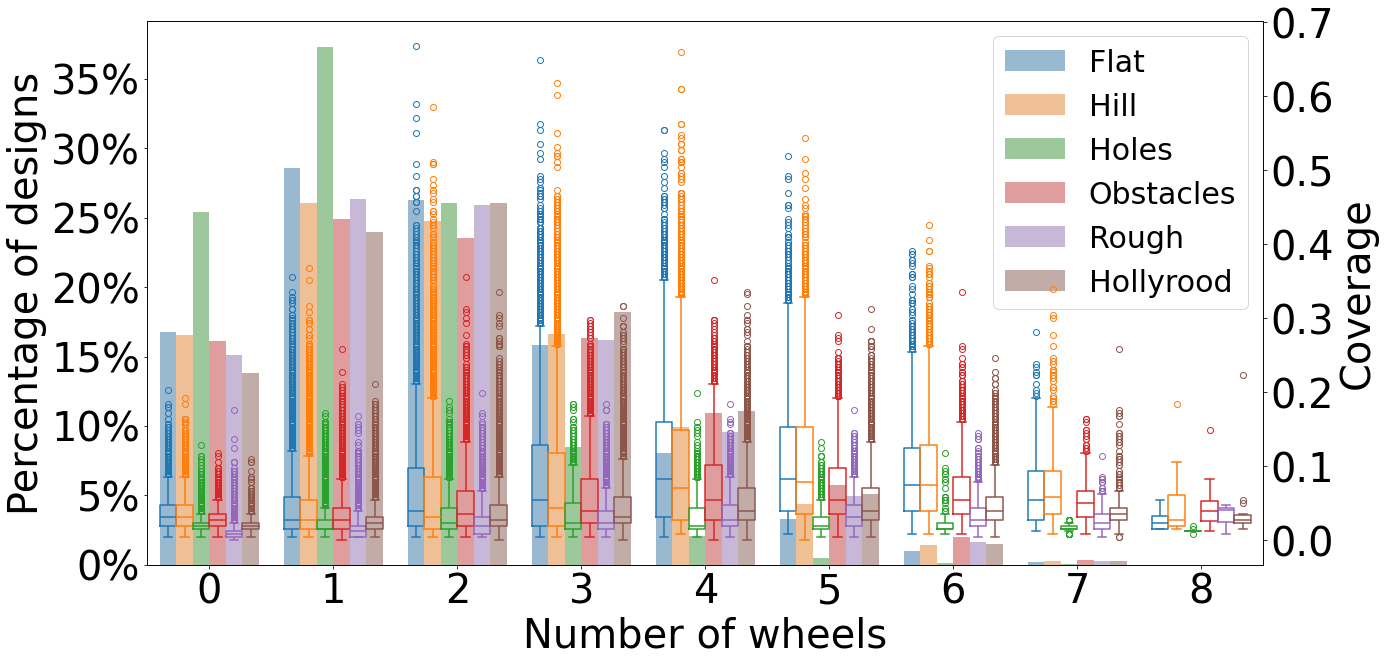

In [37]:
fig = plt.gcf()
fig.set_size_inches(20,10)
df = pd.crosstab(desc_data['environment'], desc_data['wheels'], normalize='index')
df1 = df.melt(var_name='wheels', value_name='percentage', ignore_index=False).reset_index()
ax = sns.barplot(data=df1,x="wheels",y="percentage",hue="environment",hue_order=experiments["name"],alpha=0.5)
ax.yaxis.label.set_size(40)
ax.yaxis.set_major_formatter('{x:.0%}')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles,labels=experiments["print_name"],fontsize=30)
plt.xticks(fontsize=40)
plt.yticks(fontsize=40)
ax.xaxis.label.set_size(40)
ax.set_xlabel("Number of wheels")
ax.set_ylabel("Percentage of designs")
ax = plt.twinx()
sns.boxplot(data=desc_data,x="wheels",y="fitness",hue="environment",ax=ax,fill=False,legend=False)
ax.set_ylabel("Coverage")
ax.yaxis.label.set_size(40)
ax.xaxis.set_major_formatter('{x:}')
plt.yticks(fontsize=40)
plt.savefig("img_alife25/distribution_wheels_score.png")

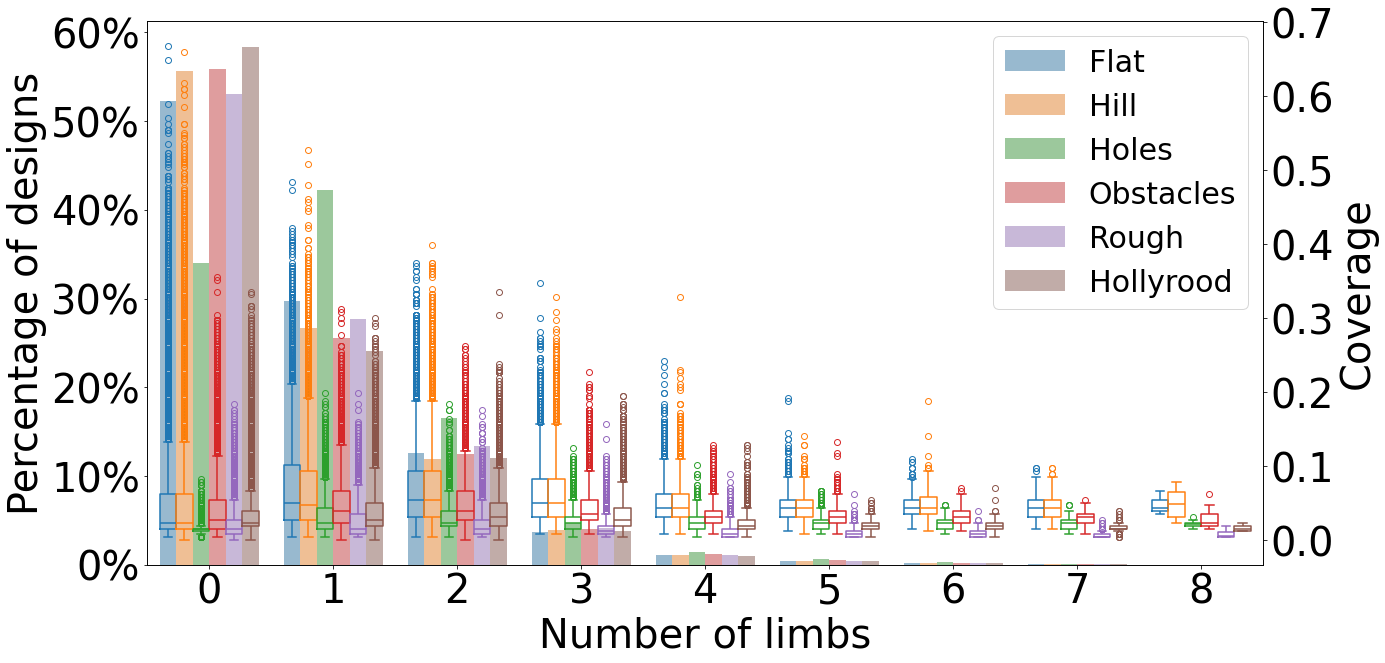

In [38]:
fig = plt.gcf()
fig.set_size_inches(20,10)
df = pd.crosstab(desc_data['environment'], desc_data['limbs'], normalize='index')
df1 = df.melt(var_name='limbs', value_name='percentage', ignore_index=False).reset_index()
ax = sns.barplot(data=df1,x="limbs",y="percentage",hue="environment",hue_order=experiments["name"],alpha=0.5)
ax.yaxis.label.set_size(40)
ax.yaxis.set_major_formatter('{x:.0%}')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles,labels=experiments["print_name"],fontsize=30)
plt.xticks(fontsize=40)
plt.yticks(fontsize=40)
ax.xaxis.label.set_size(40)
ax.set_xlabel("Number of limbs")
ax.set_ylabel("Percentage of designs")
ax = plt.twinx()
sns.boxplot(data=desc_data,x="limbs",y="fitness",hue="environment",ax=ax,fill=False,legend=False)
ax.set_ylabel("Coverage")
ax.yaxis.label.set_size(40)
ax.xaxis.set_major_formatter('{x:}')
plt.yticks(fontsize=40)
plt.savefig("img_alife25/distribution_limbs_score.png")

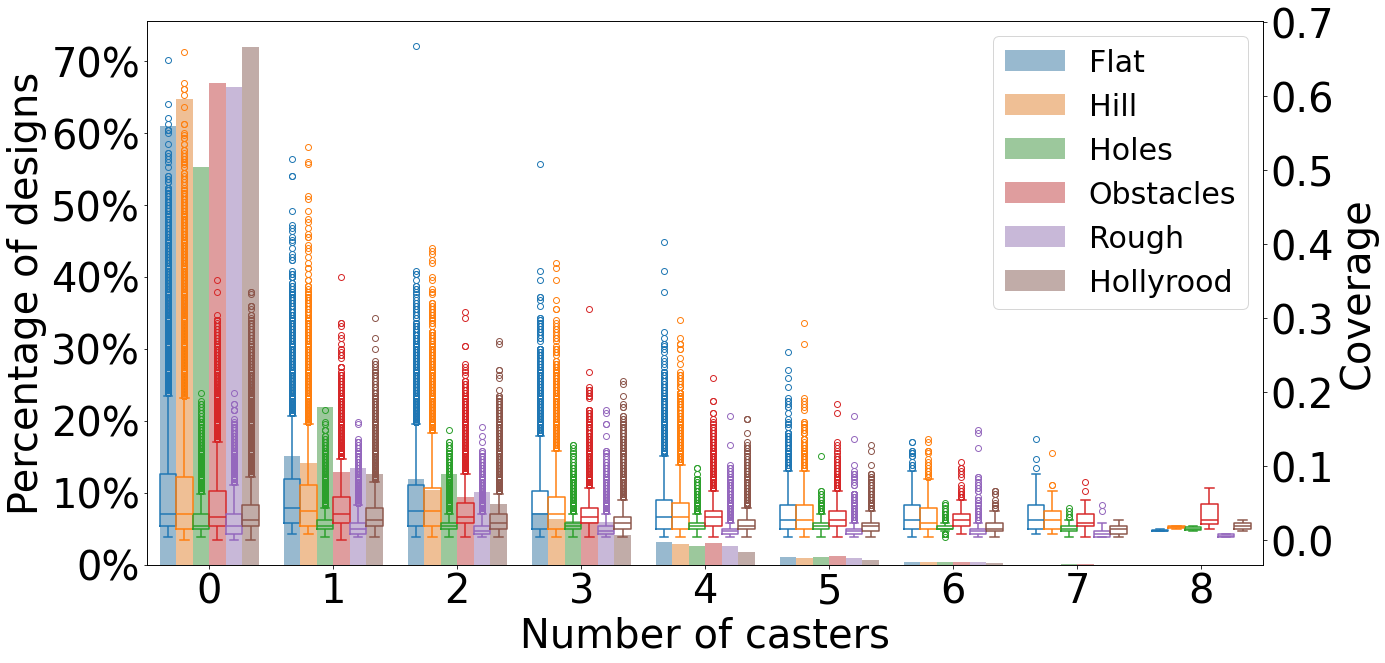

In [39]:
fig = plt.gcf()
fig.set_size_inches(20,10)
df = pd.crosstab(desc_data['environment'], desc_data['casters'], normalize='index')
df1 = df.melt(var_name='casters', value_name='percentage', ignore_index=False).reset_index()
ax = sns.barplot(data=df1,x="casters",y="percentage",hue="environment",hue_order=experiments["name"],alpha=0.5)
ax.yaxis.label.set_size(40)
ax.yaxis.set_major_formatter('{x:.0%}')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles,labels=experiments["print_name"],fontsize=30)
plt.xticks(fontsize=40)
plt.yticks(fontsize=40)
ax.xaxis.label.set_size(40)
ax.set_xlabel("Number of casters")
ax.set_ylabel("Percentage of designs")
ax = plt.twinx()
sns.boxplot(data=desc_data,x="casters",y="fitness",hue="environment",ax=ax,fill=False,legend=False)
ax.set_ylabel("Coverage")
ax.yaxis.label.set_size(40)
ax.xaxis.set_major_formatter('{x:}')
plt.yticks(fontsize=40)
plt.savefig("img_alife25/distribution_casters_score.png")

# High coverage diversity

In [22]:
top_percent = 0.1

df_top = []
for idx, exp in enumerate(experiments["name"]):
     df_top_tmp = desc_data[desc_data.environment.isin([exp])].sort_values(by='fitness', ascending=False)
     df_top_tmp = df_top_tmp.head(int(len(df_top_tmp)*(top_percent/100)))
     print(len(df_top_tmp))
     df_top.append(df_top_tmp)

df_top_desc_data = pd.concat(df_top).reset_index(drop=True)
print(len(df_top_desc_data.index))

200
182
200
190
189
200
1161


<Figure size 1440x360 with 0 Axes>

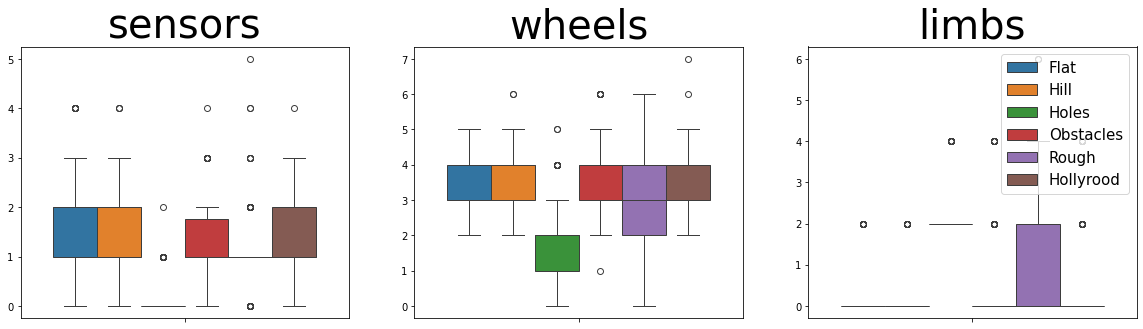

In [40]:
fig = plt.gcf()
fig.set_size_inches(20,5)
plt.figure(figsize=(20,5))
variables = ["sensors", "wheels", "limbs"]#,"casters"]
for i, c in enumerate(variables, 1):
    plt.subplot(1,3,i)
    is_legend = False
    if i == 3:
        is_legend = True
    sns.boxplot(y=c, hue="environment", data=df_top_desc_data, legend=is_legend)
    if i == 3:
      plt.legend(loc='upper right', fontsize=15, labels=experiments["print_name"])
    plt.title(c, fontsize=40)
    plt.ylabel("")
    #plt.suptitle("Top " + str(top_percent) + "%", fontsize=32)
#plt.savefig("img_alife25/high_coverage_diversity_" + str(top_percent) + ".png", bbox_inches='tight')
plt.savefig("img_alife25/features_top1_fitness.png")

In [ ]:
# Window of 10% ordered by fitness
windows = 10
window_size = []
for idx, exp in enumerate(experiments["name"]):
    window_size.append(int(desc_data[desc_data.environment.isin([exp])].shape[0] / windows))
feats = ["wheels", "sensors", "limbs"]
wheels = []
sensors = []
limbs = []
full_data = []
for window in range(windows):
    temp = []
    for idx, exp in enumerate(experiments["name"]):
        temp = desc_data[desc_data.environment.isin([exp])].sort_values(by=['fitness'], ascending=True)[window_size[idx] * window : window_size[idx] * (window + 1)]
        temp["window"] = window
        full_data.append(temp)
        # wheels.append([temp.wheels.mean(), temp.wheels.std(), temp.wheels.median(), temp.wheels.mode()[0], temp.wheels.quantile(0.75) - temp.wheels.quantile(0.25), temp.wheels.var(), window, exp, "wheels"])
        # sensors.append([temp.sensors.mean(), temp.sensors.std(), temp.sensors.median(), temp.sensors.mode()[0], temp.sensors.quantile(0.75) - temp.sensors.quantile(0.25), temp.sensors.var(), window, exp, "sensors"])
        # limbs.append([temp.limbs.mean(), temp.limbs.std(), temp.limbs.median(), temp.limbs.mode()[0], temp.limbs.quantile(0.75) - temp.limbs.quantile(0.25), temp.limbs.var(), window, exp, "limbs"])

wheels = pd.DataFrame(data=wheels, columns=["mean", "std", "median", "mode", "IQR", "var",  "window", "environment", "feature"])
sensors = pd.DataFrame(data=sensors, columns=["mean", "std", "median", "mode", "IQR", "var",  "window", "environment", "feature"])
limbs = pd.DataFrame(data=limbs, columns=["mean", "std", "median", "mode", "IQR", "var",  "window", "environment", "feature"])
windowed_data_fitness = pd.concat(full_data).reset_index(drop=True)#pd.concat([wheels, sensors, limbs]).reset_index(drop=True)
#windowed_data = pd.DataFrame(data=windowed_data, columns=["mean", "window", "environment", "feature"])
#print(windowed_data)

<Figure size 576x1440 with 0 Axes>

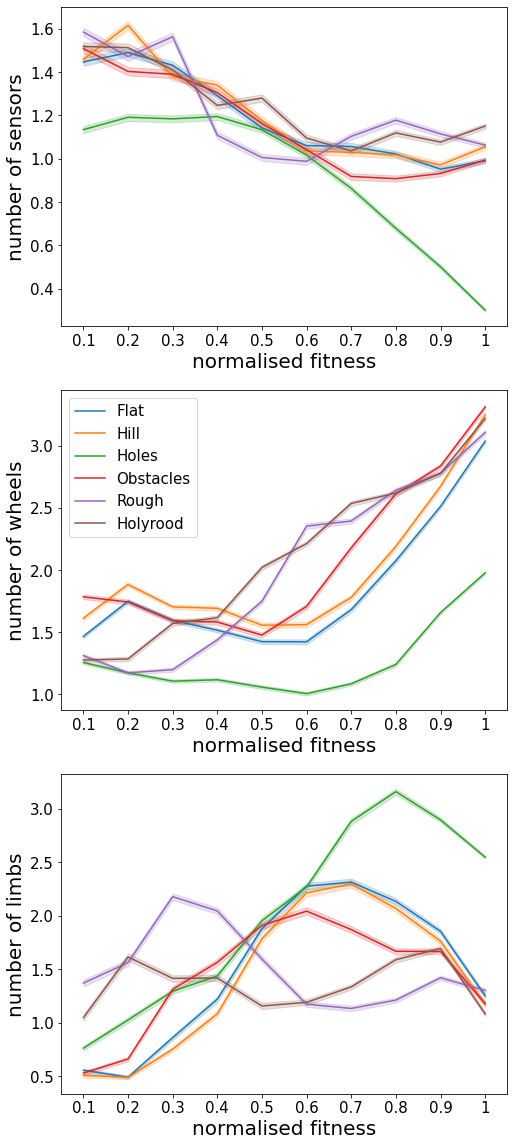

In [67]:
fig = plt.gcf()
fig.set_size_inches(8,20)
plt.figure(figsize=(8,20))
variables = [ "sensors", "wheels", "limbs"]#,"casters"]
for i, c in enumerate(variables, 1):
    plt.subplot(3,1,i)
    is_legend = False
    if i == 2:
        is_legend = True
    ax = sns.lineplot(data=windowed_data_fitness, x="window", y=c, hue="environment", legend=is_legend)
    if(is_legend):
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles=handles,loc='upper left', fontsize=15, labels=experiments["print_name"],title="")
    # plt.title(c, fontsize=20)
    plt.ylabel(f"number of {c}",fontsize=20)
    plt.xlabel("normalised fitness",fontsize=20)
    plt.xlim(-0.5, 9.5)
    plt.xticks([0,1,2,3,4,5,6,7,8,9], ['0.1','0.2', '0.3', '0.4', '0.5', '0.6', '0.7', '0.8', '0.9', '1'],fontsize=15)
    plt.yticks(fontsize=15)


    #plt.suptitle("Top " + str(top_percent) + "%", fontsize=32)
plt.savefig("img_alife25/features_trend_fitness.png", bbox_inches='tight')

<Figure size 2160x360 with 0 Axes>

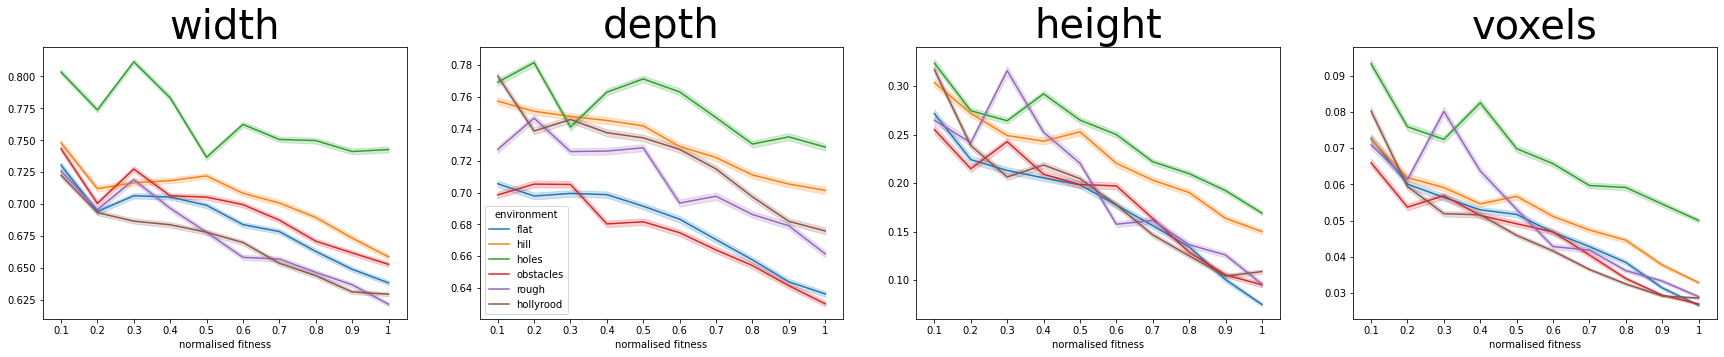

In [ ]:
fig = plt.gcf()
fig.set_size_inches(30,5)
plt.figure(figsize=(30,5))
variables = [ "width", "depth", "height", "voxels"]#,"casters"]
for i, c in enumerate(variables, 1):
    plt.subplot(1,4,i)
    is_legend = False
    if i == 2:
        is_legend = True
        plt.legend(loc='upper left', fontsize=15, labels=experiments["print_name"])
    #ax = sns.lineplot(data=windowed_data_fitness[windowed_data_fitness["feature"] == c], x="window", y="mean", hue="environment", legend=is_legend)
    ax = sns.lineplot(data=windowed_data_fitness, x="window", y=c, hue="environment", legend=is_legend)
    plt.ylabel(f"number of {c}",fontsize=20)
    plt.xlabel("normalised fitness",fontsize=20)
    plt.xlim(-0.5, 9.5)
    plt.xticks([0,1,2,3,4,5,6,7,8,9], ['0.1','0.2', '0.3', '0.4', '0.5', '0.6', '0.7', '0.8', '0.9', '1'])

    #plt.suptitle("Top " + str(top_percent) + "%", fontsize=32)
plt.savefig("img_alife25/features_trend_fitness.png", bbox_inches='tight')
plt.savefig("img_alife25/features_trend_fitness.png", bbox_inches='tight')

In [20]:
# Window of 10% ordered by replicate index
windows = 10
window_size = []
for idx, exp in enumerate(experiments["name"]):
    window_size.append(int(desc_data[desc_data.environment.isin([exp])].shape[0] / windows))
feats = ["wheels", "sensors", "limbs"]
wheels = []
sensors = []
limbs = []
full_data = []
for window in range(windows):
    temp = []
    for idx, exp in enumerate(experiments["name"]):
        temp = desc_data[desc_data.environment.isin([exp])].sort_values(by=['replicate_index'], ascending=True)[window_size[idx] * window : window_size[idx] * (window + 1)]
        temp["window"] = window
        full_data.append(temp)
        wheels.append([temp.wheels.mean(), temp.wheels.std(), temp.wheels.median(), temp.wheels.mode()[0], temp.wheels.quantile(0.75) - temp.wheels.quantile(0.25), temp.wheels.var(), window, exp, "wheels"])
        sensors.append([temp.sensors.mean(), temp.sensors.std(), temp.sensors.median(), temp.sensors.mode()[0], temp.sensors.quantile(0.75) - temp.sensors.quantile(0.25), temp.sensors.var(), window, exp, "sensors"])
        limbs.append([temp.limbs.mean(), temp.limbs.std(), temp.limbs.median(), temp.limbs.mode()[0], temp.limbs.quantile(0.75) - temp.limbs.quantile(0.25), temp.limbs.var(), window, exp, "limbs"])

wheels = pd.DataFrame(data=wheels, columns=["mean", "std", "median", "mode", "IQR", "var",  "window", "environment", "feature"])
sensors = pd.DataFrame(data=sensors, columns=["mean", "std", "median", "mode", "IQR", "var",  "window", "environment", "feature"])
limbs = pd.DataFrame(data=limbs, columns=["mean", "std", "median", "mode", "IQR", "var",  "window", "environment", "feature"])
windowed_data_generation = pd.concat(full_data).reset_index(drop=True) #pd.concat([wheels, sensors, limbs]).reset_index(drop=True)

#windowed_data = pd.DataFrame(data=windowed_data, columns=["mean", "window", "environment", "feature"])
#print(windowed_data)

<Figure size 576x1440 with 0 Axes>

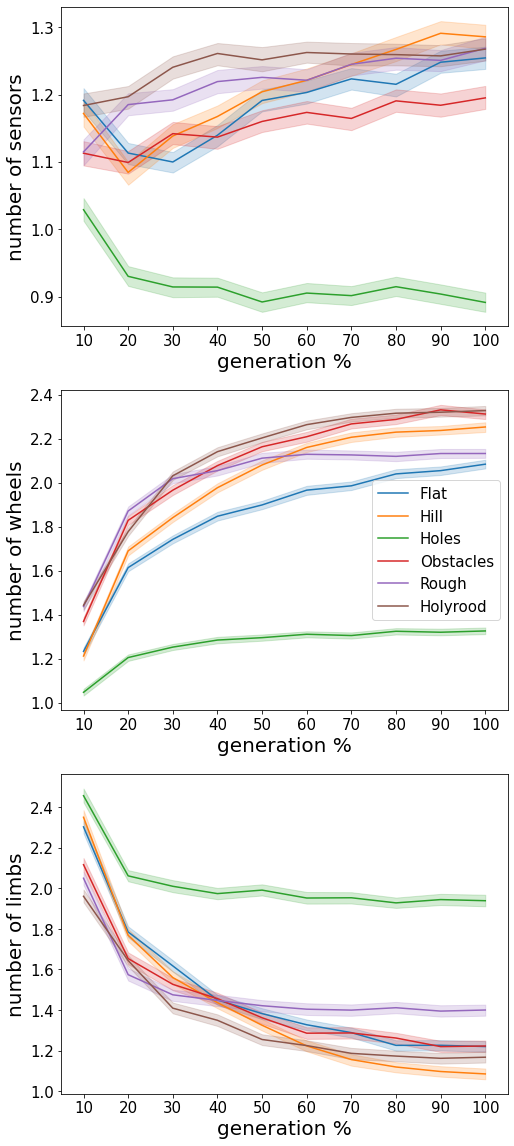

In [71]:
fig = plt.gcf()
fig.set_size_inches(8,20)
plt.figure(figsize=(8,20))
variables = [ "sensors", "wheels", "limbs"]#,"casters"]
for i, c in enumerate(variables, 1):
    plt.subplot(3,1,i)
    is_legend = False
    if i == 2:
        is_legend = True
    #ax = sns.scatterplot(data=windowed_data_generation[windowed_data_generation["feature"] == c], x="window", y="mean", hue="environment", legend=is_legend)
    ax = sns.lineplot(data=windowed_data_generation, x="window", y=c, hue="environment", legend=is_legend)
    if(is_legend):
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles=handles,loc='center right', fontsize=15, labels=experiments["print_name"],title="")
    #plt.legend(loc='upper left', fontsize=15, labels=experiments["print_name"])
    #ax.errorbar(windowed_data[windowed_data["feature"] == c]["window"], windowed_data[windowed_data["feature"] == c]["mean"], yerr= windowed_data[windowed_data["feature"] == c]["std"],fmt='o')
    
    plt.ylabel(f"number of {c}",fontsize=20)
    plt.xlabel("generation %",fontsize=20)
    plt.xlim(-0.5, 9.5)
    plt.xticks([0,1,2,3,4,5,6,7,8,9], ['10','20', '30', '40', '50', '60', '70', '80', '90', '100'],fontsize=15)
    plt.yticks(fontsize=15)

    #plt.suptitle("Top " + str(top_percent) + "%", fontsize=32)
plt.savefig("img_alife25/features_trend_generation.png", bbox_inches='tight')

<Figure size 2160x360 with 0 Axes>

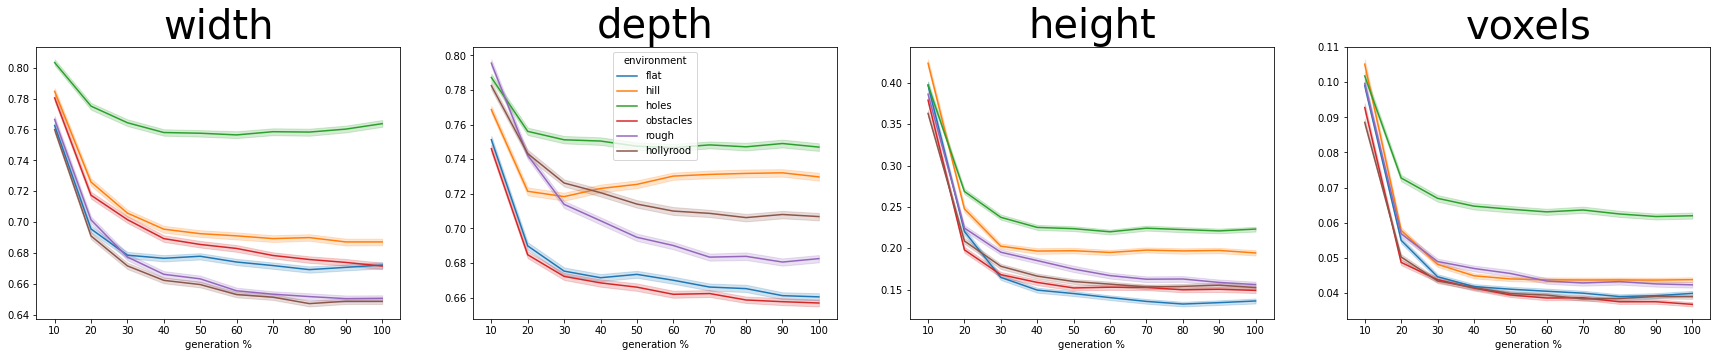

In [36]:
fig = plt.gcf()
fig.set_size_inches(30,5)
plt.figure(figsize=(30,5))
variables = [ "width", "depth", "height", "voxels"]#,"casters"]
for i, c in enumerate(variables, 1):
    plt.subplot(1,4,i)
    is_legend = False
    if i == 2:
        is_legend = True
        plt.legend(loc='upper left', fontsize=15, labels=experiments["print_name"])
    #ax = sns.scatterplot(data=windowed_data_generation[windowed_data_generation["feature"] == c], x="window", y="mean", hue="environment", legend=is_legend)
    ax = sns.lineplot(data=windowed_data_generation, x="window", y=c, hue="environment", legend=is_legend)
    #plt.legend(loc='upper left', fontsize=15, labels=experiments["print_name"])
    #ax.errorbar(windowed_data[windowed_data["feature"] == c]["window"], windowed_data[windowed_data["feature"] == c]["mean"], yerr= windowed_data[windowed_data["feature"] == c]["std"],fmt='o')
    
    plt.title(c, fontsize=40)
    plt.ylabel("")
    plt.xlabel("generation %")
    plt.xlim(-0.5, 9.5)
    plt.xticks([0,1,2,3,4,5,6,7,8,9], ['10','20', '30', '40', '50', '60', '70', '80', '90', '100'])

    #plt.suptitle("Top " + str(top_percent) + "%", fontsize=32)
# plt.savefig("img_alife25/features_trend_generation.png", bbox_inches='tight')

In [28]:
windowed_data

,mean,std,median,mode,IQR,var,window,environment,feature
0,1.232992,1.262541,1.0,0.0,2.0,1.594010,0,flat,wheels
1,1.190708,1.235247,1.0,0.0,2.0,1.525835,0,hill,wheels
2,1.046887,1.111505,1.0,0.0,2.0,1.235443,0,holes,wheels
3,1.368833,1.353517,1.0,0.0,2.0,1.832009,0,obstacles,wheels
4,1.435931,1.421488,1.0,0.0,2.0,2.020627,0,rough,wheels
...,...,...,...,...,...,...,...,...,...
175,1.082810,1.822948,0.0,0.0,2.0,3.323141,9,hill,limbs
176,1.939082,1.960125,2.0,2.0,2.0,3.842089,9,holes,limbs
177,1.221983,1.934063,0.0,0.0,2.0,3.740601,9,obstacles,limbs
178,1.356676,1.925461,0.0,0.0,2.0,3.707401,9,rough,limbs


# Chassis diversity

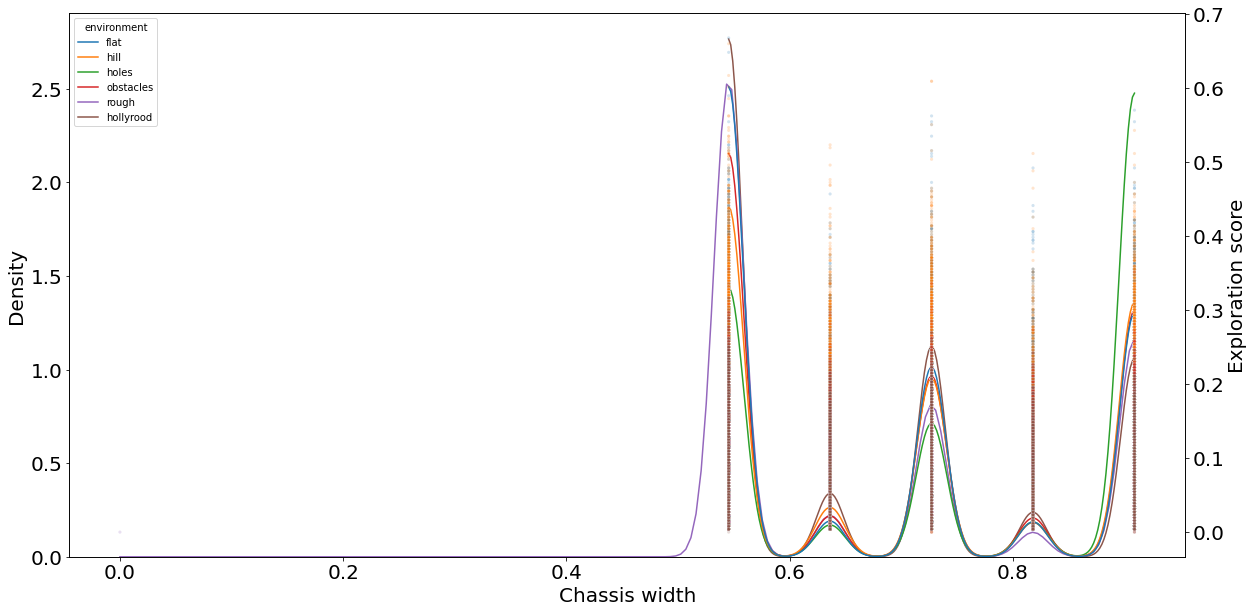

In [47]:
fig = plt.gcf()
fig.set_size_inches(20,10)
ax = sns.kdeplot(data=desc_data,x="width",hue="environment",cut=0,hue_order=experiments["name"])
ax.yaxis.label.set_size(20)
#plt.legend(["flat","terrain 1","terrain 2","terrain 3"],fontsize=20,loc=2)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.xaxis.label.set_size(20)
ax.set_xlabel("Chassis width")
ax = plt.twinx()
sns.scatterplot(data=desc_data,x="width",y="fitness",hue="environment",ax=ax,s=10,legend=False,alpha=0.2,hue_order=experiments["name"])
ax.set_ylabel("Coverage")
ax.set_ylabel("Exploration score")
ax.yaxis.label.set_size(20)
plt.yticks(fontsize=20)
plt.savefig("img_alife25/distribution_chassis_width.png", bbox_inches='tight')

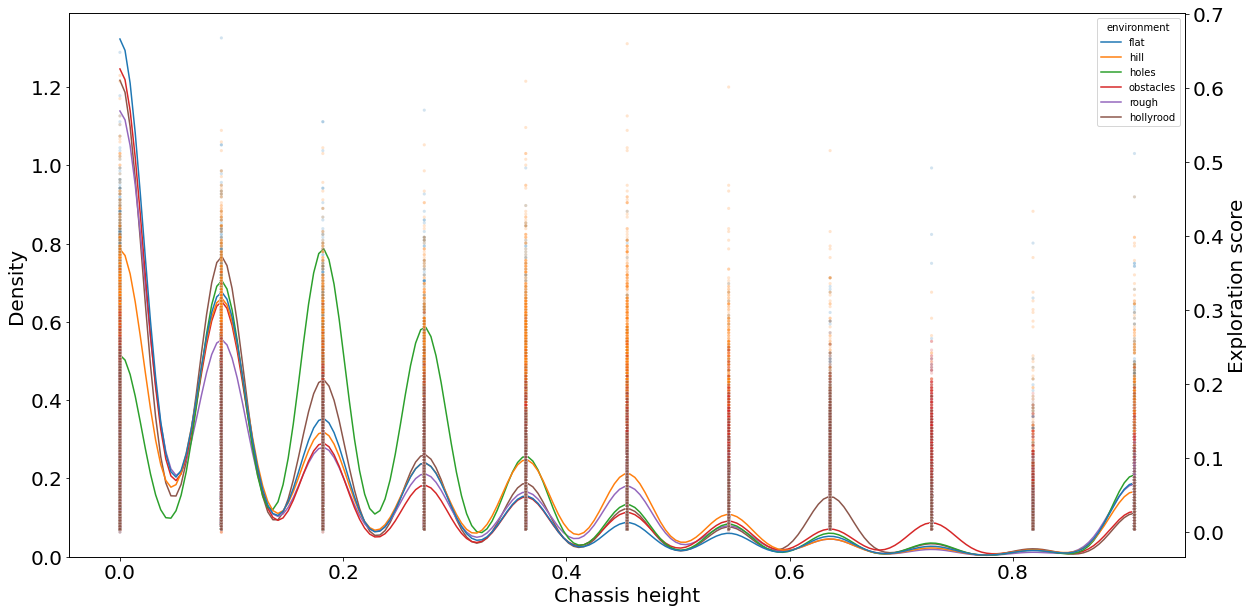

In [48]:
fig = plt.gcf()
fig.set_size_inches(20,10)
ax = sns.kdeplot(data=desc_data,x="height",hue="environment",cut=0)
ax.yaxis.label.set_size(20)
#plt.legend(["flat","terrain 1","terrain 2","terrain 3"],fontsize=20,loc=2)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.xaxis.label.set_size(20)
ax.set_xlabel("Chassis height")
ax = plt.twinx()
sns.scatterplot(data=desc_data,x="height",y="fitness",hue="environment",ax=ax,s=10,legend=False,alpha=0.2)
ax.set_ylabel("Exploration score")
ax.yaxis.label.set_size(20)
plt.yticks(fontsize=20)
plt.savefig("img_alife25/distribution_chassis_height.png", bbox_inches='tight')

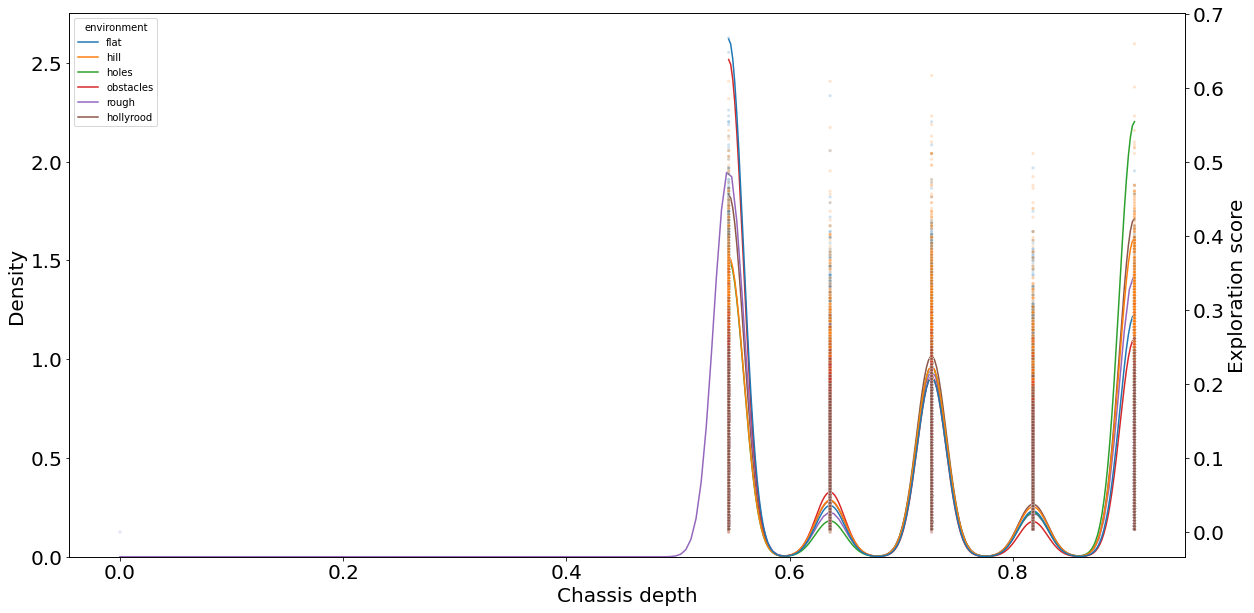

In [49]:
fig = plt.gcf()
fig.set_size_inches(20,10)
ax = sns.kdeplot(data=desc_data,x="depth",hue="environment",cut=0)
ax.yaxis.label.set_size(20)
#plt.legend(["flat","terrain 1","terrain 2","terrain 3"],fontsize=20,loc=2)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.xaxis.label.set_size(20)
ax.set_xlabel("Chassis depth")
ax = plt.twinx()
sns.scatterplot(data=desc_data,x="depth",y="fitness",hue="environment",ax=ax,s=10,legend=False,alpha=0.2)
ax.set_ylabel("Exploration score")
ax.yaxis.label.set_size(20)
plt.yticks(fontsize=20)
plt.savefig("img_alife25/distribution_chassis_depth.png", bbox_inches='tight')

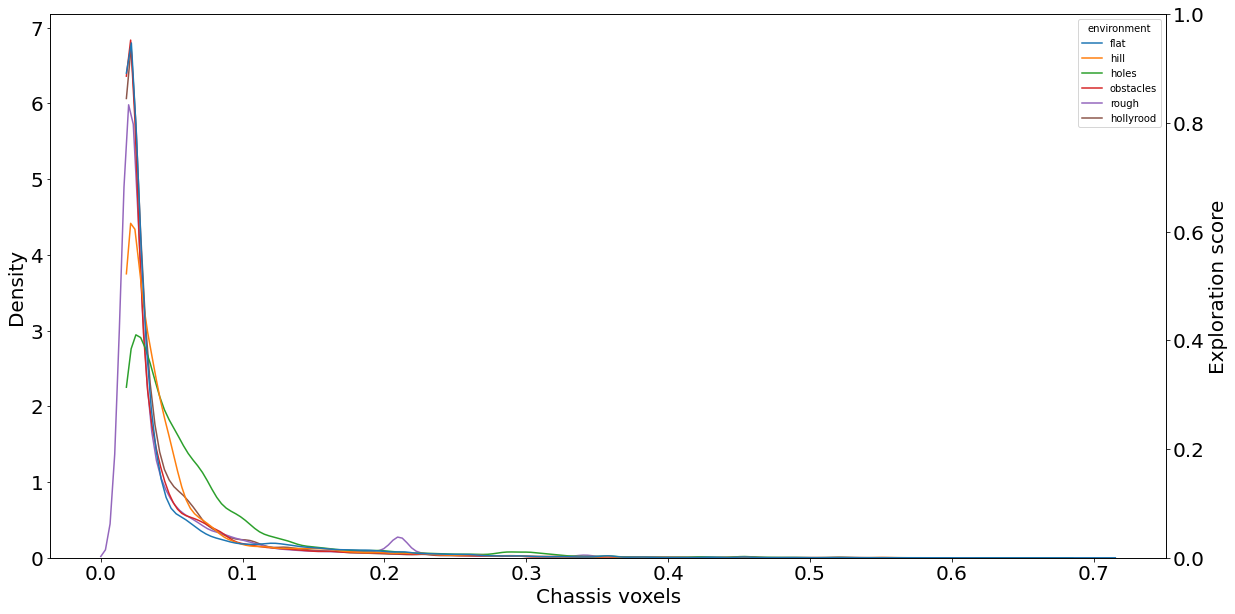

In [50]:
fig = plt.gcf()
fig.set_size_inches(20,10)
sns.scatterplot(data=desc_data,x="voxels",y="fitness",hue="environment",ax=ax,s=10,legend=False,alpha=0.2)
ax = sns.kdeplot(data=desc_data,x="voxels",hue="environment",cut=0)
ax.yaxis.label.set_size(20)
#plt.legend(["flat","terrain 1","terrain 2","terrain 3"],fontsize=20,loc=2)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.xaxis.label.set_size(20)
ax.set_xlabel("Chassis voxels")
ax = plt.twinx()
ax.set_ylabel("Exploration score")
ax.yaxis.label.set_size(20)
plt.yticks(fontsize=20)
plt.savefig("img_alife25/distribution_chassis_voxels.png", bbox_inches='tight')